**Cap 3 – Classification**

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Al igual que en el capítulo anterior, definamos los tamaños de fuente predeterminados para que las figuras sean más bonitas:

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Y vamos a crear la carpeta `images/classification` (si no existe ya), y definir la función `save_fig()` que se utiliza a través de este notebook para guardar las figuras en alta resolución para el libro:

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# MNIST

In [11]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [13]:
# extra code – it's a bit too long
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [15]:

mnist.keys()  # extra code – we only use data and target in this notebook

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [17]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [19]:
X.shape

(70000, 784)

In [21]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [23]:
y.shape

(70000,)

In [25]:
28 * 28 #Cada imagen tiene 28x28 pixeles

784

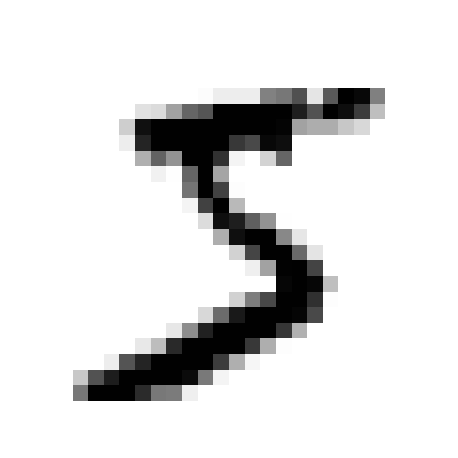

In [27]:
import matplotlib.pyplot as plt  # Importamos la librería matplotlib para graficar

# Función para graficar una imagen de un dígito
def plot_digit(image_data):
    # Redimensionamos la imagen para que tenga las dimensiones correctas (28x28 píxeles)
    image = image_data.reshape(28, 28)  # Se asume que cada imagen está representada como un vector de 784 elementos (28x28)
    
    # Usamos 'imshow' para mostrar la imagen, con un mapa de colores binario ('binary')
    plt.imshow(image, cmap="binary")
    
    # Desactivamos los ejes para que solo se vea la imagen
    plt.axis("off")

# Suponiendo que 'X' es un conjunto de datos donde cada imagen es un vector de 784 elementos
some_digit = X[0]  # Tomamos la primera imagen de 'X'
plot_digit(some_digit)  # Graficamos la imagen

# Guardamos la figura (opcional)
save_fig("some_digit_plot")  # 'save_fig' se asume como una función que guarda la figura, no definida en el código.
plt.show()  # Mostramos la imagen en pantalla

In [29]:
y[0] #Es lo que nos dice la etiqueta

'5'

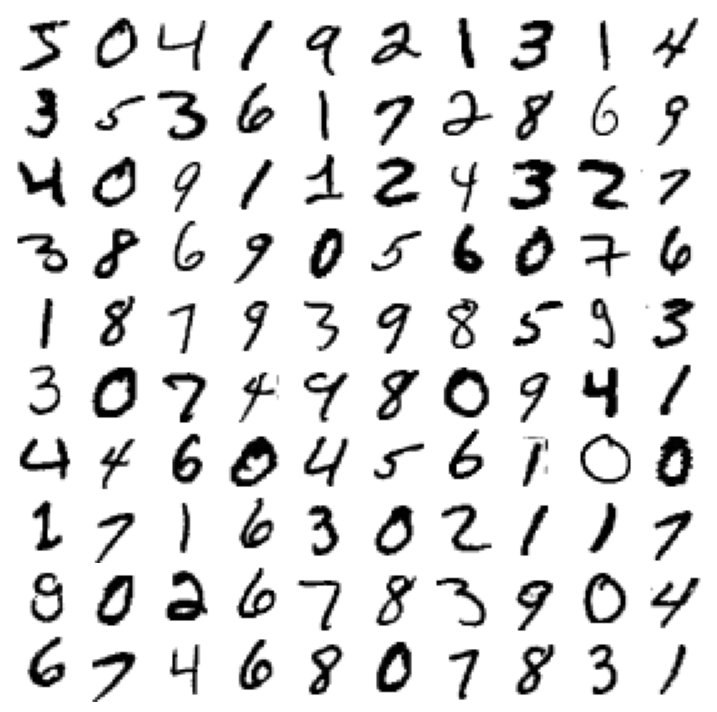

In [33]:
# Establecemos el tamaño de la figura, en este caso 9x9 pulgadas.
plt.figure(figsize=(9, 9))

# Creamos un ciclo que recorrerá las primeras 100 imágenes de 'X' (las primeras 100 muestras del conjunto de datos)
for idx, image_data in enumerate(X[:100]):
    # Usamos 'subplot' para colocar cada imagen en una cuadrícula de 10x10
    plt.subplot(10, 10, idx + 1)  # 10 filas, 10 columnas, índice de la imagen (idx+1)
    
    # Llamamos a 'plot_digit' para graficar cada imagen
    plot_digit(image_data)

# Ajustamos el espacio entre las subgráficas (el espacio entre las imágenes)
plt.subplots_adjust(wspace=0, hspace=0)

# Guardamos la figura en un archivo, sin ajustar el layout (con 'tight_layout=False' para más control)
save_fig("more_digits_plot", tight_layout=False)

# Mostramos la figura generada
plt.show()

In [35]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Entrenamiento de un clasificador binario

Identificar solo un dígito: 5 o no 5

In [39]:
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [50]:
# Mostramos los primeros 12 valores de y_train_5
print(y_train_5[:12])

[ True False False False False False False False False False False  True]


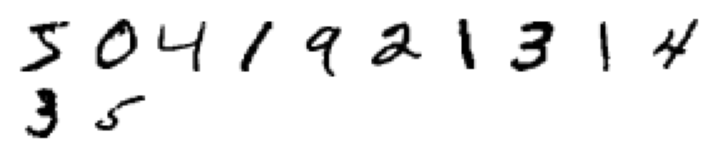

In [52]:
# Establecemos el tamaño de la figura, en este caso 9x9 pulgadas.
plt.figure(figsize=(9, 9))

# Creamos un ciclo que recorrerá las primeras 100 imágenes de 'X' (las primeras 100 muestras del conjunto de datos)
for idx, image_data in enumerate(X[:12]):
    # Usamos 'subplot' para colocar cada imagen en una cuadrícula de 10x10
    plt.subplot(10, 10, idx + 1)  # 10 filas, 10 columnas, índice de la imagen (idx+1)
    
    # Llamamos a 'plot_digit' para graficar cada imagen
    plot_digit(image_data)

# Ajustamos el espacio entre las subgráficas (el espacio entre las imágenes)
plt.subplots_adjust(wspace=0, hspace=0)

# Guardamos la figura en un archivo, sin ajustar el layout (con 'tight_layout=False' para más control)
save_fig("more_digits_plot_12_5_binari", tight_layout=False)

# Mostramos la figura generada
plt.show()

In [41]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf 

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [43]:
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [45]:
sgd_clf.predict([some_digit])

array([ True])

# Medidas de desempeño

## Medición de la precisión mediante validación cruzada

In [56]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [58]:
# Importamos la clase StratifiedKFold para realizar la validación cruzada estratificada
# que garantiza que la proporción de clases en cada pliegue sea similar a la del conjunto completo.
from sklearn.model_selection import StratifiedKFold

# Importamos 'clone' de la biblioteca 'sklearn.base', que nos permite crear copias de los estimadores.
from sklearn.base import clone

# Inicializamos el objeto StratifiedKFold con 3 pliegues (divisiones del conjunto de datos).
# Si el conjunto de datos no está ya barajado, se puede agregar 'shuffle=True' para mezclarlo antes de dividirlo.
skfolds = StratifiedKFold(n_splits=3)  # n_splits=3 significa que el conjunto de datos se divide en 3 partes

# Recorremos cada pliegue de la validación cruzada estratificada. 
# 'train_index' contiene los índices de entrenamiento y 'test_index' los índices de prueba.
for train_index, test_index in skfolds.split(X_train, y_train_5):
    # Hacemos una copia del clasificador (sgd_clf) para entrenar y evaluar en cada pliegue sin alterar el original
    clone_clf = clone(sgd_clf)
    
    # Creamos subconjuntos de los datos de entrenamiento y sus etiquetas correspondientes
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    
    # Creamos el subconjunto de prueba para este pliegue
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    # Entrenamos el clasificador clonado con los datos del pliegue de entrenamiento
    clone_clf.fit(X_train_folds, y_train_folds)
    
    # Realizamos predicciones sobre los datos de prueba para este pliegue
    y_pred = clone_clf.predict(X_test_fold)
    
    # Contamos cuántas predicciones fueron correctas
    n_correct = sum(y_pred == y_test_fold)
    
    # Calculamos y mostramos la tasa de aciertos (precisión) para este pliegue
    print(n_correct / len(y_pred))  # Imprime la precisión del modelo para este pliegue

0.95035
0.96035
0.9604


In [60]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [62]:
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [64]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

## Matriz de confusión

In [69]:
# Importamos la función cross_val_predict de scikit-learn.
# Esta función realiza validación cruzada y devuelve las predicciones generadas por el modelo para cada muestra.
from sklearn.model_selection import cross_val_predict

# Usamos cross_val_predict para generar las predicciones del clasificador 'sgd_clf'
# a través de una validación cruzada con 3 pliegues (cv=3).
# 'X_train' son las características de entrenamiento y 'y_train_5' son las etiquetas (en formato binario o de clase).
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [75]:
# Importamos la función 'confusion_matrix' desde 'sklearn.metrics'.
# Esta función calcula la matriz de confusión entre las etiquetas verdaderas y las predicciones.
from sklearn.metrics import confusion_matrix

# Calculamos la matriz de confusión comparando las etiquetas verdaderas (y_train_5) con las predicciones obtenidas (y_train_pred)
cm = confusion_matrix(y_train_5, y_train_pred)

# Imprimimos la matriz de confusión
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

- Cada **fila** representa una clase real.
- Cada **columna** una clase prevista.
- <code> TN </code>: $53892$
- <code> FP </code>: $687$

- <code> FN (errores de tipo II)</code>: $1891$
- <code> TP </code>: $3530$

In [77]:
# Suponemos que las predicciones para y_train_5 son perfectas, 
# es decir, las predicciones coinciden exactamente con las etiquetas reales.
y_train_perfect_predictions = y_train_5  # pretendemos que alcanzamos la perfección

# Calculamos la matriz de confusión comparando las etiquetas reales (y_train_5) 
# con las predicciones perfectas (y_train_perfect_predictions)
cm_perfect = confusion_matrix(y_train_5, y_train_perfect_predictions)

# Imprimimos la matriz de confusión para las predicciones perfectas
cm_perfect

array([[54579,     0],
       [    0,  5421]], dtype=int64)

## Precision and Recall

In [85]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)  # == 3530 / (687 + 3530)

0.8370879772350012

In [87]:
# extra code – this cell also computes the precision: TP / (FP + TP)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

0.8370879772350012

In [89]:
recall_score(y_train_5, y_train_pred)  # == 3530 / (1891 + 3530)

0.6511713705958311

In [91]:
# extra code – this cell also computes the recall: TP / (FN + TP)
cm[1, 1] / (cm[1, 0] + cm[1, 1])

0.6511713705958311

In [93]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [95]:
# extra code – this cell also computes the f1 score
cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)

0.7325171197343847

## Precision/Recall Trade-off

<code> decision_function </code> devuelve una puntuación para cada instancia 

In [98]:
# Usamos el método 'decision_function' para obtener los scores de decisión para una muestra de entrada.
# 'some_digit' es una muestra de entrada del conjunto de datos (por ejemplo, una imagen de un dígito).
y_scores = sgd_clf.decision_function([some_digit])

# Imprimimos los scores de decisión generados para 'some_digit'
y_scores

array([2164.22030239])

In [100]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [102]:
y_some_digit_pred


array([ True])

In [104]:
# extra code – just shows that y_scores > 0 produces the same result as
#              calling predict()
y_scores > 0

array([ True])

In [106]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [108]:
# Importamos la función 'cross_val_predict' desde 'sklearn.model_selection'.
# Esta función realiza validación cruzada y devuelve las predicciones generadas por el modelo para cada muestra.
from sklearn.model_selection import cross_val_predict

# Usamos 'cross_val_predict' para realizar validación cruzada y obtener los scores de decisión (raw scores).
# 'sgd_clf' es el clasificador entrenado, 'X_train' son las características de entrenamiento,
# 'y_train_5' son las etiquetas de entrenamiento (en formato binario), y 'cv=3' indica que se usarán 3 pliegues.
# 'method="decision_function"' asegura que obtenemos los scores de decisión en lugar de las predicciones de clase.
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

# Imprimimos los scores de decisión obtenidos para cada muestra durante la validación cruzada
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447])

In [110]:
# Importamos la función 'precision_recall_curve' desde 'sklearn.metrics'.
# Esta función nos permite calcular la precisión y recall en diferentes umbrales de decisión.
from sklearn.metrics import precision_recall_curve

# Calculamos las métricas de precisión, recall y los umbrales de decisión para las predicciones
# 'y_train_5' son las etiquetas verdaderas (0 o 1) y 'y_scores' son los scores de decisión del modelo.
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Imprimimos las métricas obtenidas
precisions, recalls, thresholds

(array([0.09035   , 0.09035151, 0.09035301, ..., 1.        , 1.        ,
        1.        ]),
 array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        3.68935621e-04, 1.84467810e-04, 0.00000000e+00]),
 array([-146348.56726174, -142300.00705404, -137588.97581744, ...,
          38871.26391927,   42216.05562787,   49441.43765905]))

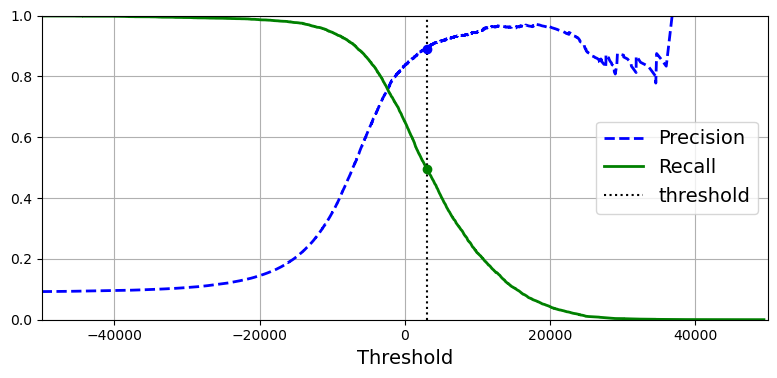

In [112]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

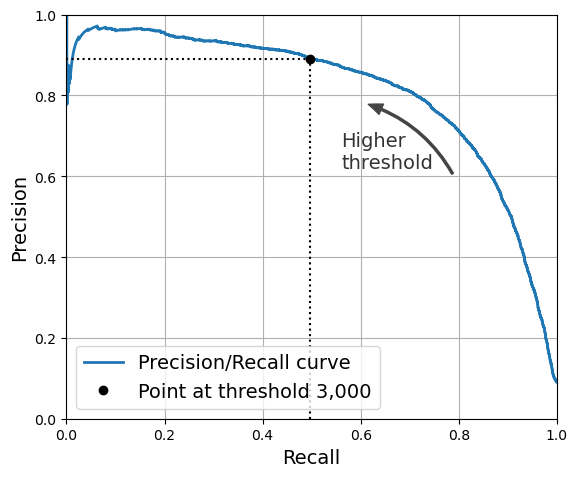

In [114]:
import matplotlib.patches as patches  # Importamos la librería para añadir una flecha curvada al gráfico

# Configuramos el tamaño de la figura (esto es solo para estética y no es necesario)
plt.figure(figsize=(6, 5))

# Dibujamos la curva de precisión vs recall usando los arrays 'precisions' y 'recalls'.
# 'linewidth=2' define el grosor de la línea, y la etiqueta es para el legend.
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# A continuación, se añaden líneas verticales y horizontales para marcar el punto
# en el que estamos interesados, en este caso el índice 'idx' que selecciona un umbral específico.
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")  # Línea vertical
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")  # Línea horizontal
plt.plot([recalls[idx]], [precisions[idx]], "ko", label="Point at threshold 3,000")  # Punto en el gráfico

# Agregamos una flecha curvada que apunta hacia el "Higher threshold"
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),  # Coordenadas iniciales y finales de la flecha
    connectionstyle="arc3,rad=.2",  # Curvatura de la flecha
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",  # Estilo de la flecha
    color="#444444"))  # Color de la flecha

# Añadimos un texto cerca de la flecha para indicar lo que significa
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")

# Configuramos las etiquetas de los ejes y los límites del gráfico
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])  # Establecemos los límites de los ejes en [0,1] para ambos
plt.grid()  # Añadimos la cuadrícula para mejorar la visualización

# Añadimos la leyenda en la parte inferior izquierda
plt.legend(loc="lower left")

# Guardamos la figura como una imagen (esto no es necesario para la visualización en pantalla)
save_fig("precision_vs_recall_plot")

# Finalmente, mostramos el gráfico generado en la pantalla
plt.show()

In [116]:
# Buscamos el índice del primer valor en la curva de precisión que sea mayor o igual a 0.90.
# 'precisions >= 0.90' crea un array de booleanos que es True cuando la precisión es >= 0.90.
# '.argmax()' devuelve el índice del primer valor True.
idx_for_90_precision = (precisions >= 0.90).argmax()

# Usamos el índice encontrado para obtener el umbral correspondiente a esa precisión.
threshold_for_90_precision = thresholds[idx_for_90_precision]

# Imprimimos el umbral correspondiente a una precisión del 90%
threshold_for_90_precision

3370.0194991439557

In [118]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [120]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [122]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

## The ROC Curve

In [128]:
# Importamos la función 'roc_curve' desde 'sklearn.metrics'.
# Esta función se utiliza para calcular los valores de la Curva ROC (Receiver Operating Characteristic).
from sklearn.metrics import roc_curve

# Calculamos los valores de la Curva ROC: 
# 'y_train_5' son las etiquetas reales (0 o 1), y 'y_scores' son los scores de decisión del modelo.
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

# Imprimimos los valores de la Curva ROC
fpr, tpr, thresholds

(array([0.        , 0.        , 0.        , ..., 0.99937705, 0.99937705,
        1.        ]),
 array([0.00000000e+00, 1.84467810e-04, 9.22339052e-04, ...,
        9.99815532e-01, 1.00000000e+00, 1.00000000e+00]),
 array([             inf,   49441.43765905,   36801.60697028, ...,
        -105763.22240074, -106527.45300471, -146348.56726174]))

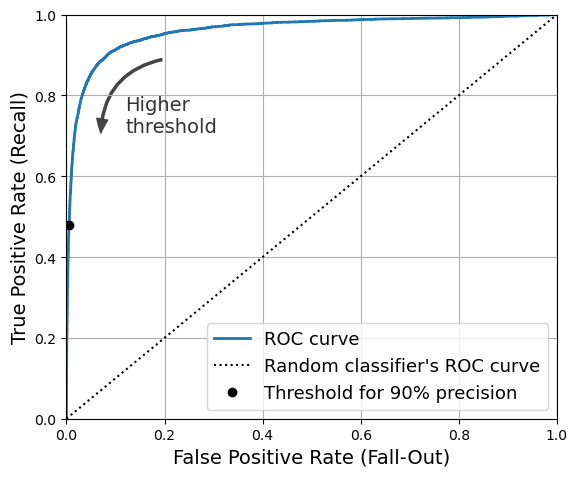

In [130]:
import matplotlib.patches as patches  # Importamos la librería para añadir una flecha curvada al gráfico

# Encontramos el índice del umbral correspondiente a una precisión del 90% en la curva de precisión y recall.
# 'threshold_for_90_precision' es el umbral para 90% de precisión calculado previamente.
# 'thresholds' son los umbrales de decisión generados por 'roc_curve'.
# Buscamos el índice donde el umbral es menor o igual al valor de 'threshold_for_90_precision' y obtenemos el índice máximo.
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()

# Obtenemos los valores de TPR y FPR correspondientes a ese umbral específico.
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

# Configuramos el tamaño de la figura para mejorar la visualización (esto es solo por estética)
plt.figure(figsize=(6, 5))

# Dibujamos la curva ROC en el gráfico
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")

# Dibujamos la línea diagonal que representa el clasificador aleatorio (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

# Marcamos el punto correspondiente al umbral para una precisión del 90% en la curva ROC
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# Añadimos una flecha curvada en el gráfico para resaltar la parte superior de la curva ROC
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),  # Coordenadas de la flecha (punto inicial y final)
    connectionstyle="arc3,rad=.4",  # Curvatura de la flecha
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",  # Estilo de la flecha
    color="#444444"))  # Color de la flecha

# Añadimos texto cerca de la flecha para explicar que estamos indicando un "umbral más alto"
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")

# Configuramos las etiquetas de los ejes X e Y y otras configuraciones del gráfico
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()  # Activamos la cuadrícula para mejorar la legibilidad
plt.axis([0, 1, 0, 1])  # Establecemos los límites de los ejes en el rango [0, 1]
plt.legend(loc="lower right", fontsize=13)  # Añadimos la leyenda en la esquina inferior derecha

# Guardamos la figura como una imagen
save_fig("roc_curve_plot")

# Finalmente, mostramos el gráfico generado en pantalla
plt.show()

 **Curva ROC**

La **curva ROC** (Receiver Operating Characteristic) es una herramienta para evaluar el rendimiento de modelos de clasificación binaria. Nos muestra la relación entre la **Tasa de Falsos Positivos** (FPR) y la **Tasa de Verdaderos Positivos** (TPR) a medida que cambiamos el umbral de decisión.


**Definiciones clave:**

- **TPR (True Positive Rate)** o **Sensibilidad / Recuperación**:
  $$  \text{TPR} = \frac{TP}{TP + FN}$$
  - Eje Y de la curva ROC.
  - Mide la proporción de ejemplos positivos correctamente clasificados.

- **FPR (False Positive Rate)** o **Fall-Out**:
  $$\text{FPR} = \frac{FP}{FP + TN}$$
  - Eje X de la curva ROC.
  - Mide la proporción de ejemplos negativos incorrectamente clasificados como positivos.

- **TNR (True Negative Rate)** o **Especificidad**:
  $$ \text{TNR} = \frac{TN}{TN + FP}$$
  - Mide la proporción de ejemplos negativos correctamente clasificados como negativos.


Interpretación de la Curva ROC:
- **Curva ideal**: Se acerca a la esquina superior izquierda, donde la **TPR** es alta y la **FPR** es baja.
- **Diagonal aleatoria**: Representa un clasificador aleatorio, con un **AUC** de 0.5.
- **AUC (Área Bajo la Curva)**: Una **AUC cercana a 1** indica un buen modelo, mientras que una **AUC cercana a 0.5** sugiere un modelo sin capacidad discriminatoria.

**Usos:**
- Permite comparar modelos y seleccionar el mejor ajustando el umbral de decisión según la necesidad de **precisión** o **recall**.

In [132]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9604938554008616

**Advertencia:** la siguiente celda puede tardar unos minutos en ejecutarse.

In [142]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
forest_clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [144]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [145]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

El modelo predice que la primera imagen es positiva con un $89$\% de probabibilidad y que la segunda es negativa con un $99$\%

Estas son probabilidades estimadas. Entre las imágenes que el modelo clasificó como positivas con una probabilidad entre el 50% y el 60%, en realidad hay alrededor del 94% de imágenes positivas:

In [151]:
# Seleccionamos los índices de las muestras donde la probabilidad del modelo 
# para la clase positiva (índice 1) está entre 0.50 y 0.60.
idx_50_to_60 = (y_probas_forest[:, 1] > 0.50) & (y_probas_forest[:, 1] < 0.60)

# Calculamos la proporción de ejemplos positivos (y_train_5) entre las muestras seleccionadas.
# 'y_train_5[idx_50_to_60]' selecciona las etiquetas verdaderas correspondientes a esas muestras,
# y 'idx_50_to_60.sum()' cuenta cuántas muestras cumplen con la condición de probabilidad.
print(f"{(y_train_5[idx_50_to_60]).sum() / idx_50_to_60.sum():.1%}")

94.0%


In [153]:
# 'y_probas_forest' son las probabilidades predichas por el modelo para cada clase.
# Extraemos las probabilidades de la clase positiva (índice 1).
y_scores_forest = y_probas_forest[:, 1]

# Calculamos la curva de precisión y recall utilizando las probabilidades obtenidas
# 'y_train_5' son las etiquetas verdaderas y 'y_scores_forest' las probabilidades de la clase positiva.
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

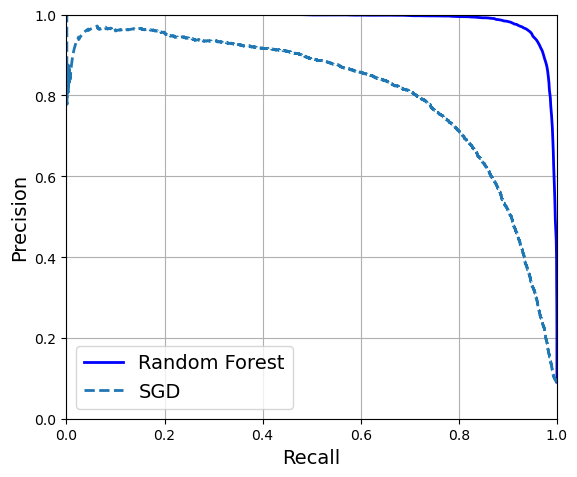

In [157]:
# Establecemos el tamaño de la figura para mejorar la visualización (esto es solo por estética)
plt.figure(figsize=(6, 5))

# Graficamos la curva de precisión-recall para Random Forest
# 'recalls_forest' y 'precisions_forest' son las tasas de recall y precisión obtenidas previamente para Random Forest.
# El estilo de la línea es una línea continua ('b-' indica color azul con línea continua).
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")

# Graficamos la curva de precisión-recall para SGD
# 'recalls' y 'precisions' son las tasas de recall y precisión obtenidas previamente para el clasificador SGD.
# El estilo de la línea es una línea discontinua ('--' indica línea punteada).
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# Añadimos etiquetas para los ejes X e Y
plt.xlabel("Recall")  # El eje X muestra el Recall
plt.ylabel("Precision")  # El eje Y muestra la Precision

# Ajustamos los límites de los ejes para que estén en el rango [0, 1] en ambos casos
plt.axis([0, 1, 0, 1])

# Añadimos una cuadrícula para mejorar la visualización
plt.grid()

# Añadimos la leyenda para diferenciar las dos curvas
plt.legend(loc="lower left")

# Guardamos el gráfico generado como un archivo (como imagen)
save_fig("pr_curve_comparison_plot")

# Mostramos el gráfico en la pantalla
plt.show()

La curva <code> Randome Forest </code> se ve mucho mejor que <code> SGD </code>, ya que se acerca mucho más a la esquina superior derecha.

Podríamos usar `cross_val_predict(forest_clf, X_train, y_train_5, cv=3)` para calcular `y_train_pred_forest`, pero como ya tenemos las probabilidades estimadas, podemos usar el umbral predeterminado de 50% de probabilidad para obtener las mismas predicciones mucho más rápido:

In [160]:
# Calculamos las predicciones basadas en las probabilidades de la clase positiva.
# 'y_probas_forest[:, 1]' extrae las probabilidades predichas para la clase positiva (índice 1).
# Luego, aplicamos un umbral de 50% para considerar una predicción como positiva (True si la probabilidad ≥ 0.5).
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # positive proba ≥ 50%

# Calculamos el F1 score comparando las predicciones ('y_train_pred_forest') con las etiquetas reales ('y_train_5')
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [162]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [164]:
precision_score(y_train_5, y_train_pred_forest)

0.9897468089558485

In [166]:
recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402

# Clasificación multiclase

<code> Scikit-Learn </code> detecta cuando intenta utilizar un algoritmo de clasificación binaria para una tarea de clasificación multiclase y ejecuta automáticamente $OvR$ y $OvO$

Las SVM no se escalan bien a grandes conjuntos de datos, por lo que solo entrenaremos en las primeras 2000 instancias; de lo contrario, esta sección tardará mucho tiempo en ejecutarse:



In [172]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Dado que hay $10$ clases (es decir, más de $2$),  <code> Scikit-Learn </code> usó la estrategía $OvO$ y entrenó $45$ clasificadores binarios.
Recordar que para $OvO$ el número de clasificadores está dado por $\frac{N(N-1)}{2}$

In [188]:
svm_clf.fit(X_train[:2000], y_train[:2000])  # y_train, not y_train_5

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [190]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

Este código realizo $45$ predicciones (una por cada clase) y selecciono la clase que ganó más duelos.

In [192]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

El método <code> decision_function </code>, devuelve $10$ puntuaciones por instancia:una por clase.

La puntuación más álta es $9.3$ y es precisamente la correspondiente a la clase $5$.

In [182]:
class_id = some_digit_scores.argmax()
class_id

5

In [198]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [200]:
svm_clf.classes_[class_id]

'5'

Si desea que `decision_function()` devuelva las 45 puntuaciones, puede establecer el hiperparámetro `decision_function_shape` en `"ovo"`. El valor predeterminado es `"ovr"`, pero no se confunda: `SVC` siempre usa OvO para el entrenamiento. Este hiperparámetro solo determina si las 45 puntuaciones se agregan o no:

In [203]:
# extra code – shows how to get all 45 OvO scores if needed
svm_clf.decision_function_shape = "ovo"
some_digit_scores_ovo = svm_clf.decision_function([some_digit])
some_digit_scores_ovo.round(2)

array([[ 0.11, -0.21, -0.97,  0.51, -1.01,  0.19,  0.09, -0.31, -0.04,
        -0.45, -1.28,  0.25, -1.01, -0.13, -0.32, -0.9 , -0.36, -0.93,
         0.79, -1.  ,  0.45,  0.24, -0.24,  0.25,  1.54, -0.77,  1.11,
         1.13,  1.04,  1.2 , -1.42, -0.53, -0.45, -0.99, -0.95,  1.21,
         1.  ,  1.  ,  1.08, -0.02, -0.67, -0.14, -0.3 , -0.13,  0.25]])

In [205]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(random_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001


In [207]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

Número de clasificadores entrenados.

In [209]:
len(ovr_clf.estimators_)

10

In [214]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [216]:
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [217]:
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -19048.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

**Advertencia:** las dos celdas siguientes pueden tardar unos minutos cada una en ejecutarse:

In [219]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87745, 0.85835, 0.8698 ])

In [220]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

C:\Users\rsantos\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\rsantos\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\rsantos\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

# Análisis de errores

**Advertencia:** la siguiente celda tardará unos minutos en ejecutarse:

C:\Users\rsantos\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\rsantos\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\rsantos\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


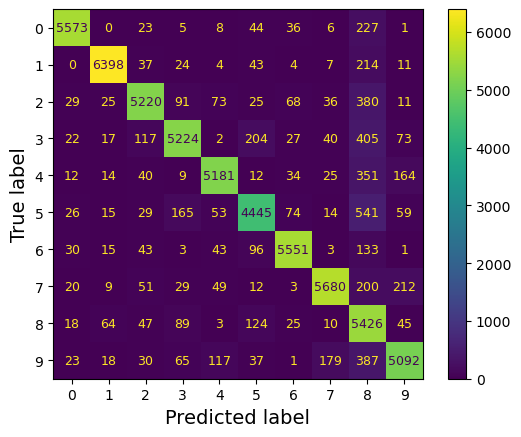

In [229]:
# Importamos la clase ConfusionMatrixDisplay de sklearn.metrics para mostrar la matriz de confusión.
from sklearn.metrics import ConfusionMatrixDisplay

# Generamos las predicciones para el conjunto de entrenamiento 'X_train_scaled' usando validación cruzada con 3 pliegues (cv=3).
# Esto permite obtener las predicciones de 'y_train_pred' sin sobreajustar el modelo al conjunto de entrenamiento.
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)

# Ajustamos el tamaño de la fuente en las gráficas para que el texto sea más pequeño.
plt.rc('font', size=9)  # extra code – hacer el texto más pequeño

# Mostramos la matriz de confusión comparando las etiquetas reales 'y_train' y las predicciones 'y_train_pred'.
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)

# Mostramos la matriz de confusión en una ventana emergente.
plt.show()

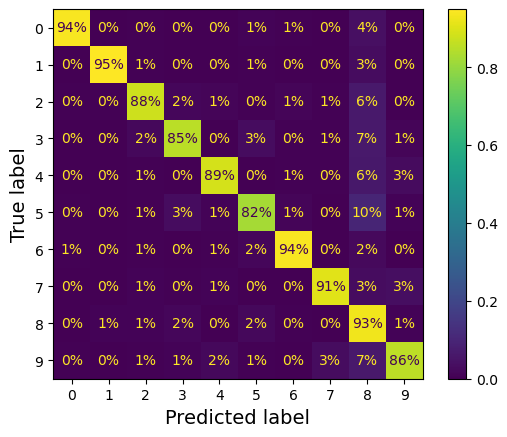

In [228]:
# Ajustamos el tamaño de la fuente en las gráficas a 10 para que el texto sea de un tamaño adecuado
plt.rc('font', size=10)  # extra code – hacer el texto de tamaño 10

# Mostramos la matriz de confusión comparando las etiquetas verdaderas 'y_train' con las predicciones 'y_train_pred'.
# Se utiliza la opción 'normalize="true"' para mostrar las proporciones (en lugar de los conteos absolutos) de cada clase.
# Además, 'values_format=".0%"' formatea los valores de la matriz de confusión como porcentajes sin decimales.
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")

# Finalmente, mostramos la matriz de confusión en una ventana emergente.
plt.show()

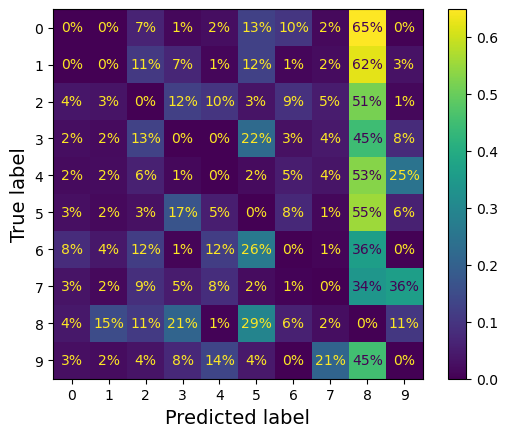

In [230]:
# Creamos un vector de pesos de muestra donde asignamos peso 1 a las muestras mal clasificadas
# (cuando la predicción no coincide con la etiqueta real) y peso 0 a las bien clasificadas.
sample_weight = (y_train_pred != y_train)

# Ajustamos el tamaño de la fuente en las gráficas a 10 para que el texto sea de un tamaño adecuado.
plt.rc('font', size=10)  # extra code – hacer el texto de tamaño 10

# Mostramos la matriz de confusión comparando las etiquetas verdaderas 'y_train' con las predicciones 'y_train_pred'.
# Usamos 'sample_weight' para darle más peso a las muestras mal clasificadas.
# Se utiliza 'normalize="true"' para mostrar las proporciones de cada clase y 'values_format=".0%"' 
# para formatear los valores como porcentajes sin decimales.
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")

# Finalmente, mostramos la matriz de confusión en una ventana emergente.
plt.show()

Pongamos todas las tramas en un par de figuras para el libro:

In [ ]:
# extra code – este bloque genera y guarda la figura 3-9 (matriz de confusión)
# Creamos una figura con dos subgráficas (subplots), una para la matriz de confusión sin normalizar y otra normalizada por fila.
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# Ajustamos el tamaño de la fuente en las gráficas a 9 para que el texto sea más pequeño.
plt.rc('font', size=9)

# En el primer subplot (axs[0]), mostramos la matriz de confusión sin normalizar.
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])
axs[0].set_title("Confusion matrix")  # Título para la primera matriz de confusión

# Ajustamos el tamaño de la fuente a 10 para la siguiente gráfica.
plt.rc('font', size=10)

# En el segundo subplot (axs[1]), mostramos la matriz de confusión normalizada por fila.
# Se muestra la matriz como un porcentaje (normalize="true" y values_format=".0%").
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")  # Título para la segunda matriz de confusión

# Guardamos la figura generada con un nombre específico, en este caso, "confusion_matrix_plot_1".
save_fig("confusion_matrix_plot_1")

# Mostramos la figura con las dos matrices de confusión.
plt.show()

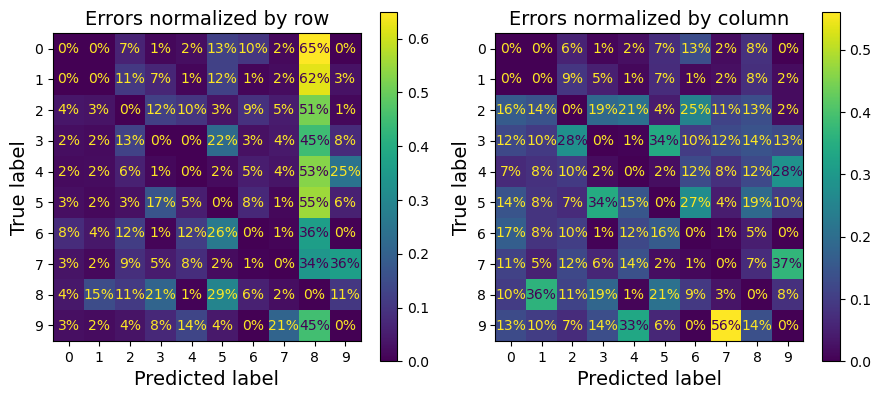

In [232]:
# extra code – este bloque genera y guarda la figura 3-10 (matriz de confusión de errores normalizados)
# Creamos una figura con dos subgráficas (subplots), una para los errores normalizados por fila y otra normalizada por columna.
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# Ajustamos el tamaño de la fuente en las gráficas a 10.
plt.rc('font', size=10)

# En el primer subplot (axs[0]), mostramos la matriz de confusión de errores normalizados por fila.
# Usamos sample_weight para dar más peso a las muestras mal clasificadas.
# Se usa "normalize='true'" para normalizar por fila, y 'values_format=".0%"' para mostrar los porcentajes sin decimales.
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0],
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
# Título para la primera matriz de confusión (errores normalizados por fila)
axs[0].set_title("Errors normalized by row")

# En el segundo subplot (axs[1]), mostramos la matriz de confusión de errores normalizados por columna.
# Normalizamos con "normalize='pred'" para que las columnas se normalicen.
# También usamos 'sample_weight' para darle más peso a las muestras mal clasificadas.
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
# Título para la segunda matriz de confusión (errores normalizados por columna)
axs[1].set_title("Errors normalized by column")

# Guardamos la figura generada con el nombre "confusion_matrix_plot_2".
save_fig("confusion_matrix_plot_2")

# Mostramos la figura con las dos matrices de confusión.
plt.show()

# Ajustamos el tamaño de la fuente a 14 para la próxima visualización.
plt.rc('font', size=14)  # hacer las fuentes grandes de nuevo

In [233]:
# Definimos las clases de interés, en este caso las clases '3' y '5'.
cl_a, cl_b = '3', '5'

# Filtramos los ejemplos del conjunto de entrenamiento 'X_train' para la clase '3' (cl_a) que fueron correctamente clasificados como '3'.
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]

# Filtramos los ejemplos del conjunto de entrenamiento 'X_train' para la clase '3' (cl_a) que fueron mal clasificados como '5' (cl_b).
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]

# Filtramos los ejemplos del conjunto de entrenamiento 'X_train' para la clase '5' (cl_b) que fueron mal clasificados como '3' (cl_a).
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]

# Filtramos los ejemplos del conjunto de entrenamiento 'X_train' para la clase '5' (cl_b) que fueron correctamente clasificados como '5'.
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

In [ ]:
# extra code – this cell generates and saves Figure 3–11
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")
save_fig("error_analysis_digits_plot")
plt.show()

Nota: Hay otras maneras de codificar un gráfico como este, pero es un poco difícil acertar con las etiquetas de los ejes:
* usando [GridSpecs anidadas](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/gridspec_nested.html)
* fusionando todos los dígitos de cada bloque en una sola imagen (luego usando subgráficos de 2×2). Por ejemplo:
```python
X_aa[:25].reshape(5, 5, 28, 28).transpose(0, 2, 1, 3).reshape(5 * 28, 5 * 28)
```
* usando [subfiguras](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subfigures.html) (desde Matplotlib 3.4)

# Clasificación multietiqueta

In [255]:
y_train[:30]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4', '3', '5', '3',
       '6', '1', '7', '2', '8', '6', '9', '4', '0', '9', '1', '1', '2',
       '4', '3', '2', '7'], dtype=object)

In [247]:
# Importamos las librerías necesarias.
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Creamos una variable booleana que es True para los valores de y_train mayores o iguales a '7' y False para los menores.
y_train_large = (y_train >= '7')
y_train_large

array([False, False, False, ..., False, False,  True])

In [257]:
y_train_large[:30]

array([False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False,  True, False,  True,
       False,  True, False, False,  True, False, False, False, False,
       False, False,  True])

In [259]:
# Creamos una variable booleana que es True para los valores impares de y_train, convirtiéndolos a tipo int8 antes de hacer el módulo.
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_train_odd[:30]

array([ True, False, False,  True,  True, False,  True,  True,  True,
       False,  True,  True,  True, False,  True,  True, False, False,
       False,  True, False, False,  True,  True,  True, False, False,
        True, False,  True])

In [265]:
# Combinamos las dos variables booleanas anteriores en una nueva matriz de etiquetas multilabel.
# Esto crea un array de dos columnas: una que indica si el número es mayor o igual a 7, y otra que indica si es impar.
y_multilabel = np.c_[y_train_large, y_train_odd]
y_multilabel[:5]

array([[False,  True],
       [False, False],
       [False, False],
       [False,  True],
       [ True,  True]])

In [243]:
# Creamos un clasificador KNN (K-Nearest Neighbors) sin especificar el número de vecinos (por defecto será 5).
knn_clf = KNeighborsClassifier()

# Entrenamos el clasificador KNN con las características de entrenamiento 'X_train' y las etiquetas multilabel 'y_multilabel'.
knn_clf.fit(X_train, y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [267]:
knn_clf.predict([some_digit])

array([[False,  True]])

**Advertencia**: la siguiente celda puede tardar unos minutos en ejecutarse:

In [270]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
y_train_knn_pred

array([[False,  True],
       [False, False],
       [False, False],
       ...,
       [False,  True],
       [False, False],
       [ True, False]])

In [272]:
# Calculamos la puntuación F1 usando el valor de "y_multilabel" (etiquetas reales) y las predicciones de KNN "y_train_knn_pred".
# La puntuación F1 es una métrica que combina la precisión y la recuperación en una única medida, útil especialmente cuando hay un desequilibrio de clases.

# "average='macro'" calcula la puntuación F1 de manera independiente para cada etiqueta y luego calcula el promedio de estas puntuaciones.
# El "average='macro'" no toma en cuenta el tamaño de las clases, lo que significa que da el mismo peso a cada etiqueta.

f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

In [274]:
# Importamos la clase ClassifierChain desde sklearn.multioutput, que permite manejar problemas de clasificación multilabel.
from sklearn.multioutput import ClassifierChain

# Creamos una instancia del modelo de cadena de clasificadores (ClassifierChain).
# En este caso, estamos utilizando un clasificador SVC (Support Vector Classification) y la validación cruzada se realiza con 3 pliegues (cv=3).
# También fijamos una semilla aleatoria (random_state=42) para garantizar resultados reproducibles.
chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)

# Entrenamos el modelo de cadenas de clasificadores con las primeras 2000 muestras de X_train y las correspondientes etiquetas multilabel de y_multilabel.
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

,estimator estimator: estimatorThe base estimator from which the classifier chain is built.,SVC()
,"order order: array-like of shape (n_outputs,) or 'random', default=NoneIf `None`, the order will be determined by the order of columns inthe label matrix Y.:: order = [0, 1, 2, ..., Y.shape[1] - 1]The order of the chain can be explicitly set by providing a list ofintegers. For example, for a chain of length 5.:: order = [1, 3, 2, 4, 0]means that the first model in the chain will make predictions forcolumn 1 in the Y matrix, the second model will make predictionsfor column 3, etc.If order is `random` a random ordering will be used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines whether to use cross validated predictions or truelabels for the results of previous estimators in the chain.Possible inputs for cv are:- None, to use true labels when fitting,- integer, to specify the number of folds in a (Stratified)KFold,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.",3
,"chain_method chain_method: {'predict', 'predict_proba', 'predict_log_proba', 'decision_function'} or list of such str's, default='predict'Prediction method to be used by estimators in the chain forthe 'prediction' features of previous estimators in the chain.- if `str`, name of the method;- if a list of `str`, provides the method names in order of preference. The method used corresponds to the first method in the list that is implemented by `base_estimator`... versionadded:: 1.5",'predict'
,"random_state random_state: int, RandomState instance or None, optional (default=None)If ``order='random'``, determines random number generation for thechain order.In addition, it controls the random seed given at each `base_estimator`at each chaining iteration. Thus, it is only used when `base_estimator`exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: bool, default=FalseIf True, chain progress is output as each model is completed... versionadded:: 1.2",False
,"base_estimator base_estimator: estimator, default=""deprecated""Use `estimator` instead... deprecated:: 1.7 `base_estimator` is deprecated and will be removed in 1.9. Use `estimator` instead.",'deprecated'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [276]:
chain_clf.predict([some_digit])

array([[0., 1.]])

# Multioutput Classification

In [278]:
# Establecemos la semilla aleatoria para garantizar la reproducibilidad del código.
np.random.seed(42)  # para hacer que este ejemplo de código sea reproducible

# Generamos ruido aleatorio (valores enteros entre 0 y 100) de tamaño igual al de X_train
# El ruido tiene la misma forma que las características de X_train (número de muestras, 784 características).
noise = np.random.randint(0, 100, (len(X_train), 784))

# Modificamos X_train añadiendo el ruido generado, creando X_train_mod (X_train con ruido).
X_train_mod = X_train + noise

# Generamos ruido aleatorio para el conjunto de prueba (X_test) de la misma forma.
noise = np.random.randint(0, 100, (len(X_test), 784))

# Modificamos X_test añadiendo el ruido generado, creando X_test_mod (X_test con ruido).
X_test_mod = X_test + noise

# Asignamos las etiquetas originales (sin modificar) de X_train y X_test a y_train_mod y y_test_mod respectivamente.
# Esto se hace para que las etiquetas sigan siendo las mismas, pero las características están "contaminadas" por el ruido.
y_train_mod = X_train
y_test_mod = X_test

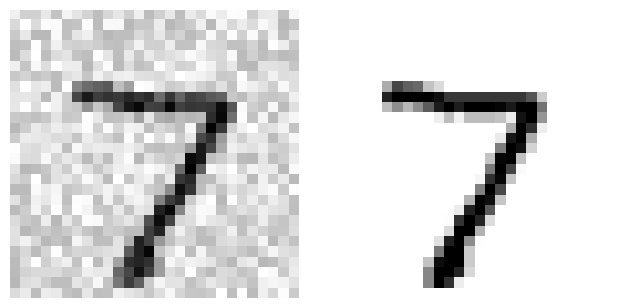

In [280]:
# extra code – this cell generates and saves Figure 3–12
plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])
save_fig("noisy_digit_example_plot")
plt.show()

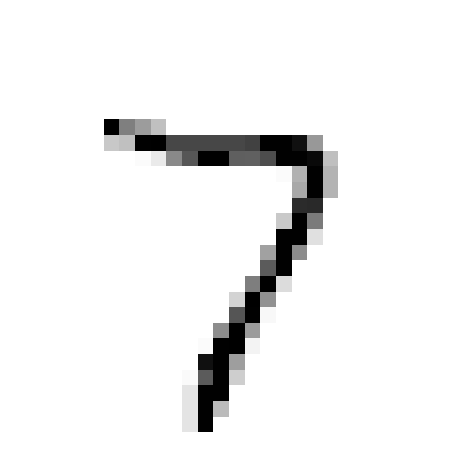

In [282]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
save_fig("cleaned_digit_example_plot")  # extra code – saves Figure 3–13
plt.show()

# Exercise solutions

## 1. An MNIST Classifier With Over 97% Accuracy

Exercise: _Try to build a classifier for the MNIST dataset that achieves over 97% accuracy on the test set. Hint: the `KNeighborsClassifier` works quite well for this task; you just need to find good hyperparameter values (try a grid search on the `weights` and `n_neighbors` hyperparameters)._

Let's start with a simple K-Nearest Neighbors classifier and measure its performance on the test set. This will be our baseline:

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)
baseline_accuracy = knn_clf.score(X_test, y_test)
baseline_accuracy

Great! A regular KNN classifier with the default hyperparameters is already very close to our goal.

Let's see if tuning the hyperparameters can help. To speed up the search, let's train only on the first 10,000 images:

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5, 6]}]

knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5)
grid_search.fit(X_train[:10_000], y_train[:10_000])

In [ ]:
grid_search.best_params_

In [ ]:
grid_search.best_score_

The score dropped, but that was expected since we only trained on 10,000 images. So let's take the best model and train it again on the full training set:

In [ ]:
grid_search.best_estimator_.fit(X_train, y_train)
tuned_accuracy = grid_search.score(X_test, y_test)
tuned_accuracy

We reached our goal of 97% accuracy! 🥳

## 2. Data Augmentation

Exercise: _Write a function that can shift an MNIST image in any direction (left, right, up, or down) by one pixel. You can use the `shift()` function from the `scipy.ndimage` module. For example, `shift(image, [2, 1], cval=0)` shifts the image two pixels down and one pixel to the right. Then, for each image in the training set, create four shifted copies (one per direction) and add them to the training set. Finally, train your best model on this expanded training set and measure its accuracy on the test set. You should observe that your model performs even better now! This technique of artificially growing the training set is called _data augmentation_ or _training set expansion_._

Let's try augmenting the MNIST dataset by adding slightly shifted versions of each image.

In [ ]:
from scipy.ndimage import shift

In [ ]:
def shift_image(image, dx, dy):
    image = image.reshape((28, 28))
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    return shifted_image.reshape([-1])

Let's see if it works:

In [ ]:
image = X_train[1000]  # some random digit to demo
shifted_image_down = shift_image(image, 0, 5)
shifted_image_left = shift_image(image, -5, 0)

plt.figure(figsize=(12, 3))
plt.subplot(131)
plt.title("Original")
plt.imshow(image.reshape(28, 28),
           interpolation="nearest", cmap="Greys")
plt.subplot(132)
plt.title("Shifted down")
plt.imshow(shifted_image_down.reshape(28, 28),
           interpolation="nearest", cmap="Greys")
plt.subplot(133)
plt.title("Shifted left")
plt.imshow(shifted_image_left.reshape(28, 28),
           interpolation="nearest", cmap="Greys")
plt.show()

Looks good! Now let's create an augmented training set by shifting every image left, right, up and down by one pixel:

In [ ]:
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx, dy in ((-1, 0), (1, 0), (0, 1), (0, -1)):
    for image, label in zip(X_train, y_train):
        X_train_augmented.append(shift_image(image, dx, dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

Let's shuffle the augmented training set, or else all shifted images will be grouped together:

In [ ]:
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

Now let's train the model using the best hyperparameters we found in the previous exercise:

In [ ]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_)

In [ ]:
knn_clf.fit(X_train_augmented, y_train_augmented)

**Warning**: the following cell may take a few minutes to run:

In [ ]:
augmented_accuracy = knn_clf.score(X_test, y_test)
augmented_accuracy

By simply augmenting the data, we've got a 0.5% accuracy boost. Perhaps it does not sound so impressive, but it actually means that the error rate dropped significantly:

In [ ]:
error_rate_change = (1 - augmented_accuracy) / (1 - tuned_accuracy) - 1
print(f"error_rate_change = {error_rate_change:.0%}")

The error rate dropped quite a bit thanks to data augmentation.

## 3. Tackle the Titanic dataset

Ejercicio: _Aborda el conjunto de datos del Titanic. Un buen punto de partida es [Kaggle](https://www.kaggle.com/c/titanic). Como alternativa, puedes descargar los datos desde https://homl.info/titanic.tgz y descomprimir este archivo tar como hiciste con los datos de las viviendas en el Capítulo 2. Esto te dará dos archivos CSV: _train.csv_ y _test.csv_, que puedes cargar con `pandas.read_csv()`. El objetivo es entrenar un clasificador que pueda predecir la columna `Survived` basándose en las demás columnas._

Vamos a buscar los datos y cargarlos:

In [286]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_titanic_data():
    tarball_path = Path("datasets/titanic.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as titanic_tarball:
            titanic_tarball.extractall(path="datasets")
    return [pd.read_csv(Path("datasets/titanic") / filename)
            for filename in ("train.csv", "test.csv")]

In [288]:
train_data, test_data = load_titanic_data()

C:\Users\rsantos\AppData\Local\Temp\ipykernel_19148\1736236013.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  titanic_tarball.extractall(path="datasets")


Los datos ya están divididos en un conjunto de entrenamiento y uno de prueba. Sin embargo, los datos de prueba *no* contienen las etiquetas: el objetivo es entrenar el mejor modelo posible con los datos de entrenamiento, luego hacer predicciones con los datos de prueba y subirlas a Kaggle para ver la puntuación final.

Echemos un vistazo a las primeras filas del conjunto de entrenamiento:

In [292]:
train_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Los atributos tienen el siguiente significado:
* **PassengerId**: un identificador único para cada pasajero
* **Survived**: ese es el objetivo; 0 significa que el pasajero no sobrevivió, mientras que 1 significa que sobrevivió.
* **Pclass**: clase del pasajero.
* **Name**, **Sex**, **Age**: se explica por sí solo
* **SibSp**: cuántos hermanos y cónyuges del pasajero había a bordo del Titanic.
* **Parch**: cuántos hijos y padres había a bordo del Titanic.
* **Ticket**: ID del billete
* **Fare**: precio pagado (en libras)
* **Cabin**: número de camarote del pasajero
* **Embarked**: lugar donde el pasajero embarcó en el Titanic

El objetivo es predecir si un pasajero sobrevivió o no en función de atributos como su edad, sexo, clase de pasajero, lugar donde embarcó, etc.

Establezcamos explícitamente la columna `PassengerId` como la columna de índice:

In [297]:
train_data = train_data.set_index("PassengerId")
test_data = test_data.set_index("PassengerId")

In [302]:
train_data.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [304]:
test_data.head(5)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Obtengamos más información para ver cuántos datos faltan:

In [306]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [308]:
train_data[train_data["Sex"]=="female"]["Age"].median()

27.0

Bien, los atributos **Edad**, **Cabina** y **Embarcado** a veces son nulos (menos de 891 valores no nulos), especialmente el de **Cabina** (el 77 % son nulos). Ignoraremos **Cabina** por ahora y nos centraremos en el resto.

El atributo **Edad** tiene aproximadamente un 19 % de valores nulos, por lo que tendremos que decidir qué hacer con ellos. 
- Reemplazar los valores nulos por la edad media parece razonable.
- Podríamos ser más inteligentes si predijéramos la edad basándonos en las demás columnas (por ejemplo, la edad media es 37 en primera clase, 29 en segunda clase y 24 en tercera clase), pero simplificaremos el proceso y usaremos solo la edad media general.

Los atributos **Nombre** y **Ticket** pueden tener algún valor, pero será un poco difícil convertirlos en números útiles que un modelo pueda procesar. Por lo tanto, por ahora, los ignoraremos.

Echemos un vistazo a los atributos numéricos:

In [314]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699113,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526507,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.416700,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


-¡Vaya, solo el 38% sobrevivió! 😭 Eso se acerca bastante al 40%, así que la precisión será una métrica razonable para evaluar nuestro modelo.

-La tarifa media fue de 32,20 £, lo cual no parece tan caro (pero probablemente era mucho dinero en aquel entonces).

-La edad media era inferior a 30 años.

Comprobemos que el objetivo es efectivamente 0 o 1:

In [319]:
train_data["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Ahora echemos un vistazo rápido a todos los atributos categóricos:

In [322]:
train_data["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [324]:
train_data["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [326]:
train_data["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

El atributo Embarcado nos dice dónde se embarcó el pasajero: C=Cherburgo, Q=Queenstown, S=Southampton.

Ahora construyamos nuestras canalizaciones de preprocesamiento, comenzando con la canalización para atributos numéricos:

In [333]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

Ahora podemos construir la canalización para los atributos categóricos:

In [331]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

Nota: el hiperparámetro `sparse` a continuación fue renombrado a `sparse_output`.

In [338]:
# Creamos un pipeline para procesar datos categóricos. Un pipeline es una secuencia de pasos para transformar los datos
# y entrenar un modelo de forma ordenada y modular.

cat_pipeline = Pipeline([
    # Primer paso: Usamos un OrdinalEncoder para transformar las categorías en valores numéricos enteros.
    ("ordinal_encoder", OrdinalEncoder()),  
    
    # Segundo paso: Usamos un SimpleImputer para manejar los valores faltantes en las columnas categóricas,
    # reemplazando los valores faltantes con la moda (el valor más frecuente) de cada columna.
    ("imputer", SimpleImputer(strategy="most_frequent")),
    
    # Tercer paso: Usamos un OneHotEncoder para convertir las categorías en columnas binarias,
    # representando cada categoría como una nueva columna con valores 0 o 1.
    ("cat_encoder", OneHotEncoder(sparse_output=False)),  
])

# Mostramos el pipeline
cat_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinal_encoder', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories

Por último, unamos las tuberías numéricas y categóricas:

In [341]:
from sklearn.compose import ColumnTransformer

num_attribs = ["Age", "SibSp", "Parch", "Fare"]
cat_attribs = ["Pclass", "Sex", "Embarked"]

preprocess_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ])
preprocess_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

¡Genial! Ahora tenemos una buena canalización de preprocesamiento que toma los datos sin procesar y genera características numéricas que podemos usar en cualquier modelo de aprendizaje automático que queramos.

In [344]:
X_train = preprocess_pipeline.fit_transform(train_data)
X_train

array([[-0.56573582,  0.43279337, -0.47367361, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.6638609 ,  0.43279337, -0.47367361, ...,  1.        ,
         0.        ,  0.        ],
       [-0.25833664, -0.4745452 , -0.47367361, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.10463705,  0.43279337,  2.00893337, ...,  0.        ,
         0.        ,  1.        ],
       [-0.25833664, -0.4745452 , -0.47367361, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.20276213, -0.4745452 , -0.47367361, ...,  0.        ,
         1.        ,  0.        ]])

No olvidemos conseguir las etiquetas:

In [349]:
y_train = train_data["Survived"]
y_train.head(5)

PassengerId
1    0
2    1
3    1
4    1
5    0
Name: Survived, dtype: int64

Ya estamos listos para entrenar un clasificador. Empecemos con un `RandomForestClassifier`:

In [352]:
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
forest_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Genial, nuestro modelo está entrenado, usémoslo para hacer predicciones en el conjunto de prueba:

In [356]:
# Primero, aplicamos el pipeline de preprocesamiento sobre los datos de prueba (test_data).
# Esto transformará las características de test_data de acuerdo con las transformaciones definidas en el pipeline 'preprocess_pipeline'.
X_test = preprocess_pipeline.transform(test_data)

# Luego, utilizamos el clasificador 'forest_clf' (por ejemplo, un Random Forest) para hacer las predicciones
# sobre los datos de prueba preprocesados, 'X_test'.
y_pred = forest_clf.predict(X_test)

Y ahora podríamos simplemente crear un archivo CSV con estas predicciones (respetando el formato esperado por Kaggle), subirlo y esperar que todo salga bien. ¡Pero un momento! Podemos hacer algo más que esperar. ¿Por qué no usamos la validación cruzada para tener una idea de la calidad de nuestro modelo?

In [359]:
forest_scores = cross_val_score(forest_clf, X_train, y_train, cv=10)
forest_scores.mean()

0.8137578027465668

¡Bueno, nada mal! Si miras la [tabla de clasificación](https://www.kaggle.com/c/titanic/leaderboard) de la competencia del Titanic en Kaggle, puedes ver que nuestra puntuación está entre el 2% superior, ¡genial! Algunos Kagglers alcanzaron el 100% de precisión, pero como puedes encontrar fácilmente la [lista de víctimas](https://www.encyclopedia-titanica.org/titanic-victims/) del Titanic, parece probable que no se usara aprendizaje automático en su rendimiento. 😆

Let's try an `SVC`:

In [363]:
from sklearn.svm import SVC

svm_clf = SVC(gamma="auto")
svm_clf

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [365]:
svm_scores = cross_val_score(svm_clf, X_train, y_train, cv=10)
svm_scores.mean()

0.8249313358302123

Great! This model looks better.

Pero en lugar de simplemente observar la precisión media en los 10 pliegues de validación cruzada, graficaremos las 10 puntuaciones de cada modelo, junto con un diagrama de caja que resalta los cuartiles inferior y superior, y "bigotes" que muestran la extensión de las puntuaciones (gracias a Nevin Yilmaz por sugerir esta visualización). Tenga en cuenta que la función `boxplot()` detecta valores atípicos (llamados "voladores") y no los incluye dentro de los bigotes. Específicamente, si el cuartil inferior es $Q_1$ y el cuartil superior es $Q_3$, entonces el rango intercuartil $IQR = Q_3 - Q_1$ (esta es la altura de la caja), y cualquier puntuación menor que $Q_1 - 1.5 \times IQR$ es un volado, al igual que cualquier puntuación mayor que $Q3 + 1.5 \times IQR$.

C:\Users\rsantos\AppData\Local\Temp\ipykernel_19148\3995193800.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([svm_scores, forest_scores], labels=("SVM", "Random Forest"))


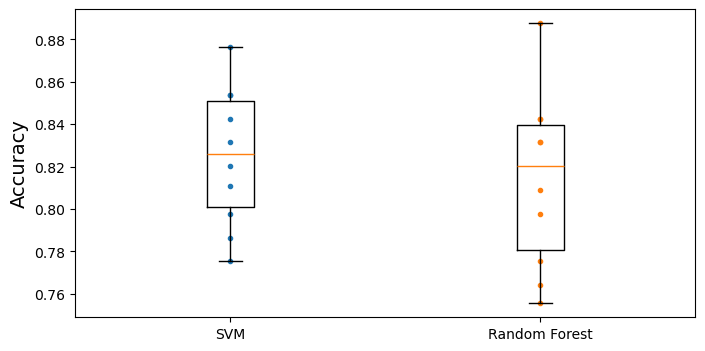

In [368]:
plt.figure(figsize=(8, 4))
plt.plot([1]*10, svm_scores, ".")
plt.plot([2]*10, forest_scores, ".")
plt.boxplot([svm_scores, forest_scores], labels=("SVM", "Random Forest"))
plt.ylabel("Accuracy")
plt.show()

El clasificador de bosque aleatorio obtuvo una puntuación muy alta en uno de los 10 pliegues, pero en general tuvo una puntuación media más baja, así como una dispersión mayor, por lo que parece que es más probable que el clasificador SVM se generalice bien.

Para mejorar aún más este resultado, podría:
* Comparar muchos más modelos y ajustar los hiperparámetros mediante validación cruzada y búsqueda en cuadrícula.
* Realizar más ingeniería de características, por ejemplo:
* Intentar convertir atributos numéricos en atributos categóricos: por ejemplo, diferentes grupos de edad tuvieron tasas de supervivencia muy diferentes (ver más abajo), por lo que puede ser útil crear una categoría de grupo de edad y usarla en lugar de la edad. De igual manera, puede ser útil tener una categoría especial para personas que viajan solas, ya que solo el 30% sobrevivió (ver más abajo).
* Reemplazar **SibSp** y **Parch** con su suma.
* Intentar identificar las partes de los nombres que se correlacionen bien con el atributo **Survived**.
* Usar la columna **Cabin**; por ejemplo, tomar su primera letra y tratarla como un atributo categórico.

In [374]:
# Creamos una nueva columna "AgeBucket" en el conjunto de datos 'train_data',
# que agrupa las edades en intervalos de 15 años.
train_data["AgeBucket"] = train_data["Age"] // 15 * 15

In [376]:
train_data.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeBucket
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,15.0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,30.0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,15.0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,30.0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,30.0


In [380]:
# Agrupamos el conjunto de datos por la columna "AgeBucket" y calculamos la media
# de la columna "Survived" para cada grupo. Esto nos dará la tasa de supervivencia
# promedio en cada intervalo de edad.
train_data[["AgeBucket", "Survived"]].groupby(['AgeBucket']).mean()

,Survived
AgeBucket,
0.0,0.576923
15.0,0.362745
30.0,0.423256
45.0,0.404494
60.0,0.240000
75.0,1.000000


In [384]:
# Creamos una nueva columna llamada "RelativesOnboard" que suma las columnas "SibSp" (número de hermanos/cónyuges a bordo)
# y "Parch" (número de padres/hijos a bordo). Esto nos da el número total de familiares a bordo para cada pasajero.
train_data["RelativesOnboard"] = train_data["SibSp"] + train_data["Parch"]

# Luego agrupamos el conjunto de datos por la columna "RelativesOnboard" (número total de familiares a bordo)
# y calculamos la media de la columna "Survived" para cada grupo. Esto nos dará la tasa de supervivencia
# promedio para cada número de familiares a bordo.
train_data[["RelativesOnboard", "Survived"]].groupby(['RelativesOnboard']).mean()

,Survived
RelativesOnboard,
0,0.303538
1,0.552795
2,0.578431
3,0.724138
4,0.200000
5,0.136364
6,0.333333
7,0.000000
10,0.000000


## 4. Spam classifier

Exercise: _Build a spam classifier (a more challenging exercise):_

* _Download examples of spam and ham from [Apache SpamAssassin's public datasets](https://homl.info/spamassassin)._
* _Unzip the datasets and familiarize yourself with the data format._
* _Split the datasets into a training set and a test set._
* _Write a data preparation pipeline to convert each email into a feature vector. Your preparation pipeline should transform an email into a (sparse) vector that indicates the presence or absence of each possible word. For example, if all emails only ever contain four words, "Hello," "how," "are," "you," then the email "Hello you Hello Hello you" would be converted into a vector [1, 0, 0, 1] (meaning [“Hello" is present, "how" is absent, "are" is absent, "you" is present]), or [3, 0, 0, 2] if you prefer to count the number of occurrences of each word._

_You may want to add hyperparameters to your preparation pipeline to control whether or not to strip off email headers, convert each email to lowercase, remove punctuation, replace all URLs with "URL," replace all numbers with "NUMBER," or even perform _stemming_ (i.e., trim off word endings; there are Python libraries available to do this)._

_Finally, try out several classifiers and see if you can build a great spam classifier, with both high recall and high precision._

In [ ]:
import tarfile

def fetch_spam_data():
    spam_root = "http://spamassassin.apache.org/old/publiccorpus/"
    ham_url = spam_root + "20030228_easy_ham.tar.bz2"
    spam_url = spam_root + "20030228_spam.tar.bz2"

    spam_path = Path() / "datasets" / "spam"
    spam_path.mkdir(parents=True, exist_ok=True)
    for dir_name, tar_name, url in (("easy_ham", "ham", ham_url),
                                    ("spam", "spam", spam_url)):
        if not (spam_path / dir_name).is_dir():
            path = (spam_path / tar_name).with_suffix(".tar.bz2")
            print("Downloading", path)
            urllib.request.urlretrieve(url, path)
            tar_bz2_file = tarfile.open(path)
            tar_bz2_file.extractall(path=spam_path)
            tar_bz2_file.close()
    return [spam_path / dir_name for dir_name in ("easy_ham", "spam")]

In [ ]:
ham_dir, spam_dir = fetch_spam_data()

Next, let's load all the emails:

In [ ]:
ham_filenames = [f for f in sorted(ham_dir.iterdir()) if len(f.name) > 20]
spam_filenames = [f for f in sorted(spam_dir.iterdir()) if len(f.name) > 20]

In [ ]:
len(ham_filenames)

In [ ]:
len(spam_filenames)

We can use Python's `email` module to parse these emails (this handles headers, encoding, and so on):

In [ ]:
import email
import email.policy

def load_email(filepath):
    with open(filepath, "rb") as f:
        return email.parser.BytesParser(policy=email.policy.default).parse(f)

In [ ]:
ham_emails = [load_email(filepath) for filepath in ham_filenames]
spam_emails = [load_email(filepath) for filepath in spam_filenames]

Let's look at one example of ham and one example of spam, to get a feel of what the data looks like:

In [ ]:
print(ham_emails[1].get_content().strip())

In [ ]:
print(spam_emails[6].get_content().strip())

Some emails are actually multipart, with images and attachments (which can have their own attachments). Let's look at the various types of structures we have:

In [ ]:
def get_email_structure(email):
    if isinstance(email, str):
        return email
    payload = email.get_payload()
    if isinstance(payload, list):
        multipart = ", ".join([get_email_structure(sub_email)
                               for sub_email in payload])
        return f"multipart({multipart})"
    else:
        return email.get_content_type()

In [ ]:
from collections import Counter

def structures_counter(emails):
    structures = Counter()
    for email in emails:
        structure = get_email_structure(email)
        structures[structure] += 1
    return structures

In [ ]:
structures_counter(ham_emails).most_common()

In [ ]:
structures_counter(spam_emails).most_common()

It seems that the ham emails are more often plain text, while spam has quite a lot of HTML. Moreover, quite a few ham emails are signed using PGP, while no spam is. In short, it seems that the email structure is useful information to have.

Now let's take a look at the email headers:

In [ ]:
for header, value in spam_emails[0].items():
    print(header, ":", value)

There's probably a lot of useful information in there, such as the sender's email address (12a1mailbot1@web.de looks fishy), but we will just focus on the `Subject` header:

In [ ]:
spam_emails[0]["Subject"]

Okay, before we learn too much about the data, let's not forget to split it into a training set and a test set:

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.array(ham_emails + spam_emails, dtype=object)
y = np.array([0] * len(ham_emails) + [1] * len(spam_emails))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

Okay, let's start writing the preprocessing functions. First, we will need a function to convert HTML to plain text. Arguably the best way to do this would be to use the great [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/) library, but I would like to avoid adding another dependency to this project, so let's hack a quick & dirty solution using regular expressions (at the risk of [un̨ho͞ly radiańcé destro҉ying all enli̍̈́̂̈́ghtenment](https://stackoverflow.com/a/1732454/38626)). The following function first drops the `<head>` section, then converts all `<a>` tags to the word HYPERLINK, then it gets rid of all HTML tags, leaving only the plain text. For readability, it also replaces multiple newlines with single newlines, and finally it unescapes html entities (such as `&gt;` or `&nbsp;`):

In [ ]:
import re
from html import unescape

def html_to_plain_text(html):
    text = re.sub('<head.*?>.*?</head>', '', html, flags=re.M | re.S | re.I)
    text = re.sub('<a\s.*?>', ' HYPERLINK ', text, flags=re.M | re.S | re.I)
    text = re.sub('<.*?>', '', text, flags=re.M | re.S)
    text = re.sub(r'(\s*\n)+', '\n', text, flags=re.M | re.S)
    return unescape(text)

Let's see if it works. This is HTML spam:

In [ ]:
html_spam_emails = [email for email in X_train[y_train==1]
                    if get_email_structure(email) == "text/html"]
sample_html_spam = html_spam_emails[7]
print(sample_html_spam.get_content().strip()[:1000], "...")

And this is the resulting plain text:

In [ ]:
print(html_to_plain_text(sample_html_spam.get_content())[:1000], "...")

Great! Now let's write a function that takes an email as input and returns its content as plain text, whatever its format is:

In [ ]:
def email_to_text(email):
    html = None
    for part in email.walk():
        ctype = part.get_content_type()
        if not ctype in ("text/plain", "text/html"):
            continue
        try:
            content = part.get_content()
        except: # in case of encoding issues
            content = str(part.get_payload())
        if ctype == "text/plain":
            return content
        else:
            html = content
    if html:
        return html_to_plain_text(html)

In [ ]:
print(email_to_text(sample_html_spam)[:100], "...")

Let's throw in some stemming! We will use the Natural Language Toolkit ([NLTK](http://www.nltk.org/)):

In [ ]:
import nltk

stemmer = nltk.PorterStemmer()
for word in ("Computations", "Computation", "Computing", "Computed", "Compute",
             "Compulsive"):
    print(word, "=>", stemmer.stem(word))

We will also need a way to replace URLs with the word "URL". For this, we could use hard core [regular expressions](https://mathiasbynens.be/demo/url-regex) but we will just use the [urlextract](https://github.com/lipoja/URLExtract) library:

In [ ]:
# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# if running this notebook on Colab or Kaggle, we just pip install urlextract
if IS_COLAB or IS_KAGGLE:
    %pip install -q -U urlextract

**Note:** inside a Jupyter notebook, always use `%pip` instead of `!pip`, as `!pip` may install the library inside the wrong environment, while `%pip` makes sure it's installed inside the currently running environment.

In [ ]:
import urlextract # may require an Internet connection to download root domain
                  # names

url_extractor = urlextract.URLExtract()
some_text = "Will it detect github.com and https://youtu.be/7Pq-S557XQU?t=3m32s"
print(url_extractor.find_urls(some_text))

We are ready to put all this together into a transformer that we will use to convert emails to word counters. Note that we split sentences into words using Python's `split()` method, which uses whitespaces for word boundaries. This works for many written languages, but not all. For example, Chinese and Japanese scripts generally don't use spaces between words, and Vietnamese often uses spaces even between syllables. It's okay in this exercise, because the dataset is (mostly) in English.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class EmailToWordCounterTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, strip_headers=True, lower_case=True,
                 remove_punctuation=True, replace_urls=True,
                 replace_numbers=True, stemming=True):
        self.strip_headers = strip_headers
        self.lower_case = lower_case
        self.remove_punctuation = remove_punctuation
        self.replace_urls = replace_urls
        self.replace_numbers = replace_numbers
        self.stemming = stemming
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        X_transformed = []
        for email in X:
            text = email_to_text(email) or ""
            if self.lower_case:
                text = text.lower()
            if self.replace_urls and url_extractor is not None:
                urls = list(set(url_extractor.find_urls(text)))
                urls.sort(key=lambda url: len(url), reverse=True)
                for url in urls:
                    text = text.replace(url, " URL ")
            if self.replace_numbers:
                text = re.sub(r'\d+(?:\.\d*)?(?:[eE][+-]?\d+)?', 'NUMBER', text)
            if self.remove_punctuation:
                text = re.sub(r'\W+', ' ', text, flags=re.M)
            word_counts = Counter(text.split())
            if self.stemming and stemmer is not None:
                stemmed_word_counts = Counter()
                for word, count in word_counts.items():
                    stemmed_word = stemmer.stem(word)
                    stemmed_word_counts[stemmed_word] += count
                word_counts = stemmed_word_counts
            X_transformed.append(word_counts)
        return np.array(X_transformed)

Let's try this transformer on a few emails:

In [ ]:
X_few = X_train[:3]
X_few_wordcounts = EmailToWordCounterTransformer().fit_transform(X_few)
X_few_wordcounts

This looks about right!

Now we have the word counts, and we need to convert them to vectors. For this, we will build another transformer whose `fit()` method will build the vocabulary (an ordered list of the most common words) and whose `transform()` method will use the vocabulary to convert word counts to vectors. The output is a sparse matrix.

In [ ]:
from scipy.sparse import csr_matrix

class WordCounterToVectorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vocabulary_size=1000):
        self.vocabulary_size = vocabulary_size
    def fit(self, X, y=None):
        total_count = Counter()
        for word_count in X:
            for word, count in word_count.items():
                total_count[word] += min(count, 10)
        most_common = total_count.most_common()[:self.vocabulary_size]
        self.vocabulary_ = {word: index + 1
                            for index, (word, count) in enumerate(most_common)}
        return self
    def transform(self, X, y=None):
        rows = []
        cols = []
        data = []
        for row, word_count in enumerate(X):
            for word, count in word_count.items():
                rows.append(row)
                cols.append(self.vocabulary_.get(word, 0))
                data.append(count)
        return csr_matrix((data, (rows, cols)),
                          shape=(len(X), self.vocabulary_size + 1))

In [ ]:
vocab_transformer = WordCounterToVectorTransformer(vocabulary_size=10)
X_few_vectors = vocab_transformer.fit_transform(X_few_wordcounts)
X_few_vectors

In [ ]:
X_few_vectors.toarray()

What does this matrix mean? Well, the 99 in the second row, first column, means that the second email contains 99 words that are not part of the vocabulary. The 11 next to it means that the first word in the vocabulary is present 11 times in this email. The 9 next to it means that the second word is present 9 times, and so on. You can look at the vocabulary to know which words we are talking about. The first word is "the", the second word is "of", etc.

In [ ]:
vocab_transformer.vocabulary_

We are now ready to train our first spam classifier! Let's transform the whole dataset:

In [ ]:
from sklearn.pipeline import Pipeline

preprocess_pipeline = Pipeline([
    ("email_to_wordcount", EmailToWordCounterTransformer()),
    ("wordcount_to_vector", WordCounterToVectorTransformer()),
])

X_train_transformed = preprocess_pipeline.fit_transform(X_train)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_clf = LogisticRegression(max_iter=1000, random_state=42)
score = cross_val_score(log_clf, X_train_transformed, y_train, cv=3)
score.mean()

Over 98.5%, not bad for a first try! :) However, remember that we are using the "easy" dataset. You can try with the harder datasets, the results won't be so amazing. You would have to try multiple models, select the best ones and fine-tune them using cross-validation, and so on.

But you get the picture, so let's stop now, and just print out the precision/recall we get on the test set:

In [ ]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = preprocess_pipeline.transform(X_test)

log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train_transformed, y_train)

y_pred = log_clf.predict(X_test_transformed)

print(f"Precision: {precision_score(y_test, y_pred):.2%}")
print(f"Recall: {recall_score(y_test, y_pred):.2%}")